In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score

In [77]:
sns.set_style('darkgrid')

In [78]:
df = pd.read_csv('data/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [79]:
df.shape

(303, 14)

In [80]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [81]:
df.dtypes.to_frame(name='dtype')

,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [82]:
df.duplicated().sum()

np.int64(1)

In [83]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [85]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

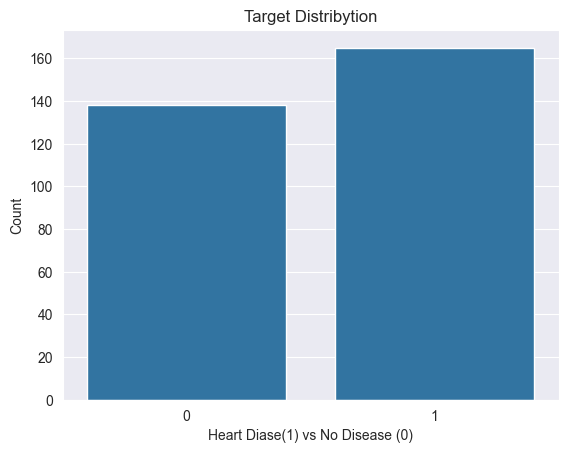

In [86]:
sns.countplot(
    data=df,
    x='target'
)

plt.title('Target Distribytion')
plt.xlabel('Heart Diase(1) vs No Disease (0)')
plt.ylabel('Count')
plt.show()

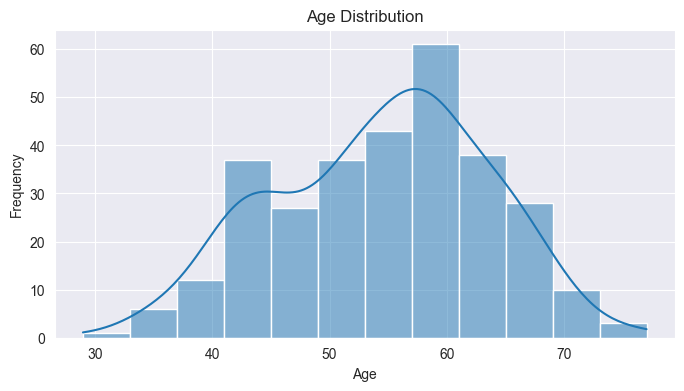

In [87]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

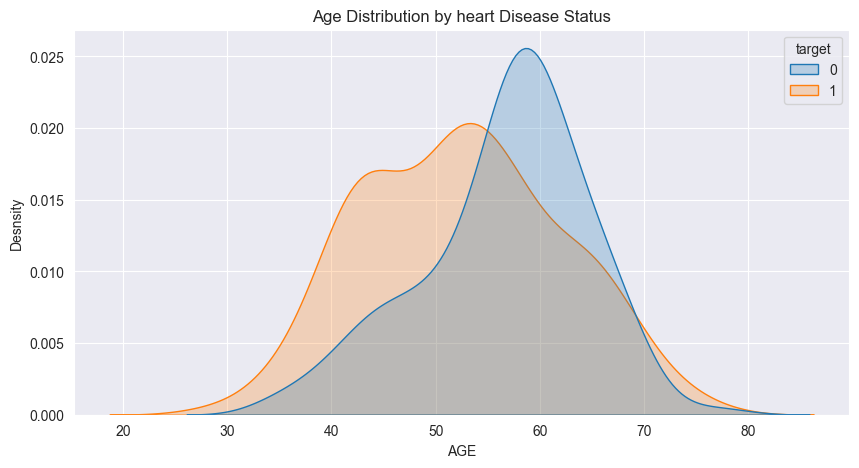

In [88]:
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df,
    x='age',
    hue='target',
    fill=True
)

plt.title('Age Distribution by heart Disease Status')
plt.xlabel('AGE')
plt.ylabel('Desnsity')
plt.show()

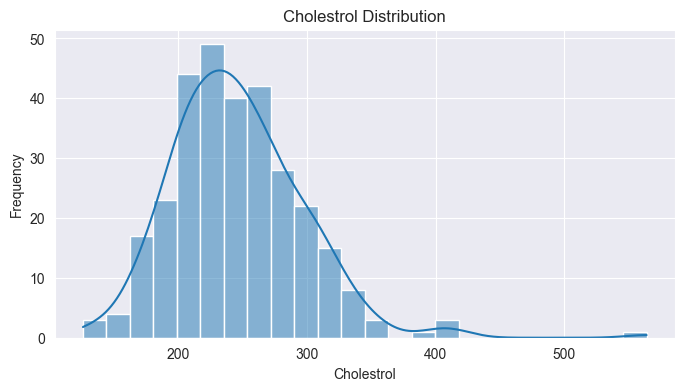

In [89]:
plt.figure(figsize=(8,4))
sns.histplot(df['chol'], kde=True)
plt.title('Cholestrol Distribution')
plt.xlabel('Cholestrol')
plt.ylabel('Frequency')
plt.show()

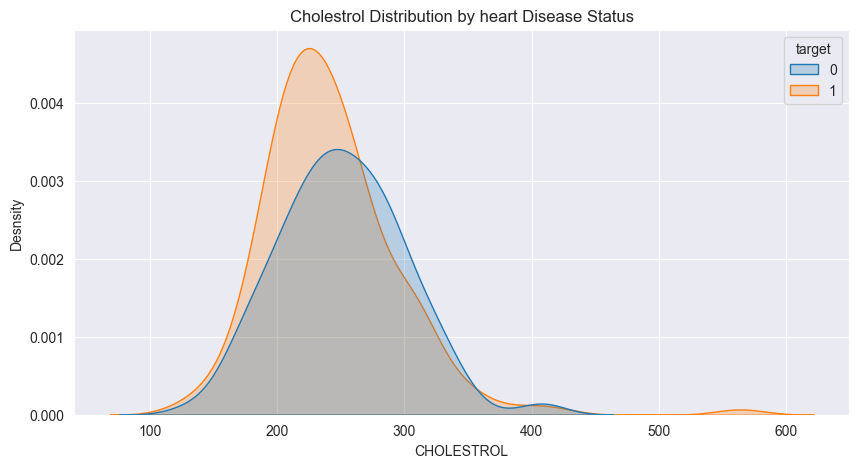

In [90]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x='chol',
    hue='target',
    fill=True
)

plt.title('Cholestrol Distribution by heart Disease Status')
plt.xlabel('CHOLESTROL')
plt.ylabel('Desnsity')
plt.show()

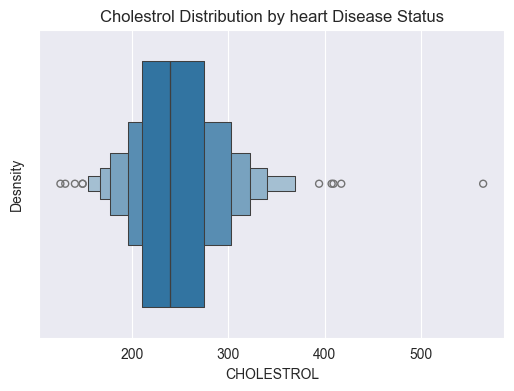

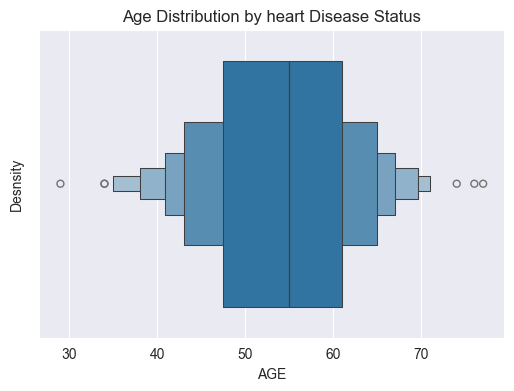

In [91]:
plt.figure(figsize=(6, 4))
sns.boxenplot(
    x=df['chol']
)
plt.title('Cholestrol Distribution by heart Disease Status')
plt.xlabel('CHOLESTROL')
plt.ylabel('Desnsity')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxenplot(
    x=df['age']
)
plt.title('Age Distribution by heart Disease Status')
plt.xlabel('AGE')
plt.ylabel('Desnsity')
plt.show()

In [92]:
corr_matrix = df.corr()

df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


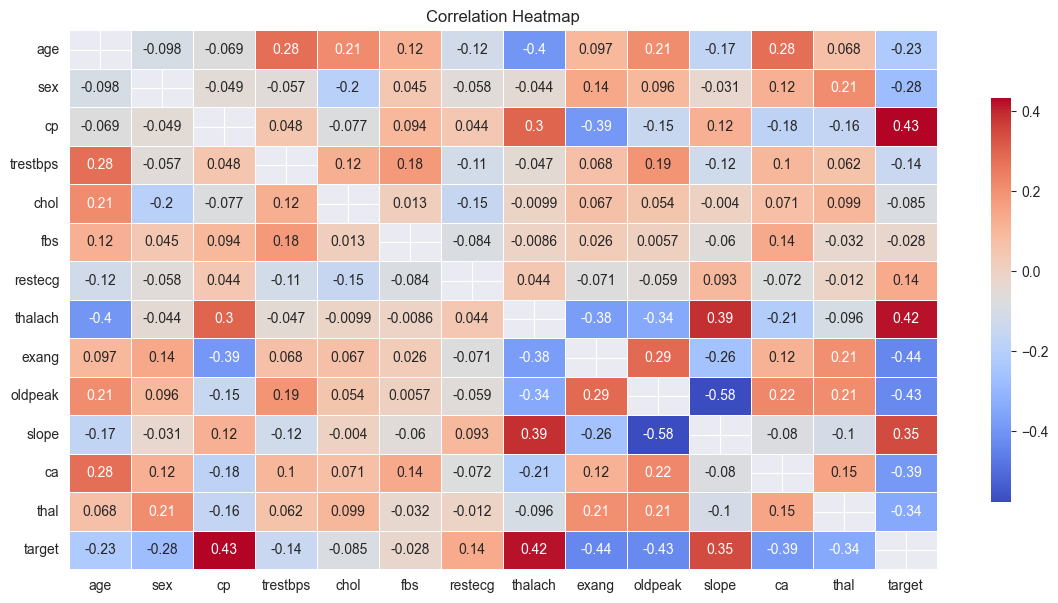

In [93]:
np.fill_diagonal(corr_matrix.values, np.nan)

plt.figure(figsize=(14, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidth=0.5,
    linecolor='white',
    cbar_kws={
        'shrink':0.75
    }
)

plt.title('Correlation Heatmap')
plt.show()



In [94]:
corr_matrix['target'].sort_values(ascending=False)

cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
target           NaN
Name: target, dtype: float64

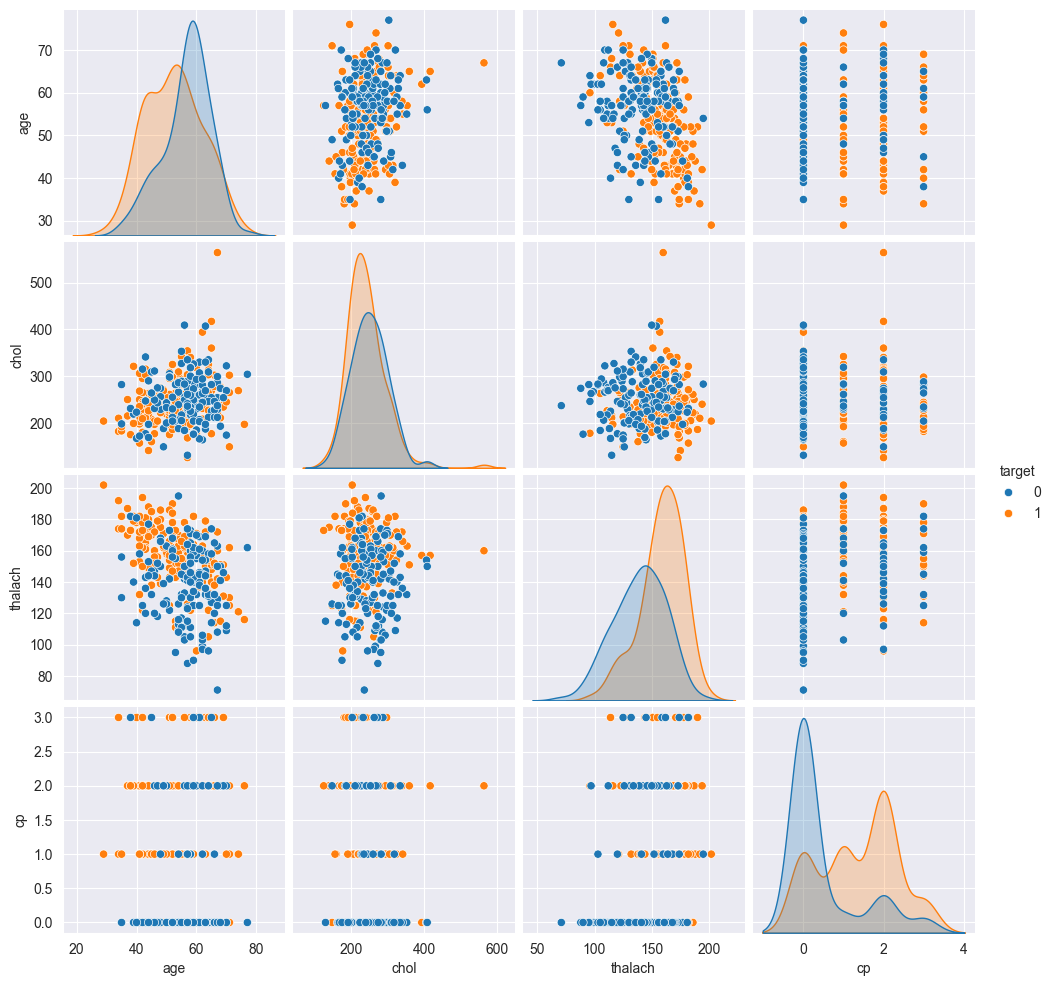

In [95]:
sns.pairplot(
    df[['age', 'chol', 'thalach', 'cp', 'target']], hue='target'
)

In [96]:
X = df.drop('target', axis=1)
y = df['target']

In [97]:
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42

)

for train_index, test_index in splitter.split(X, y):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

print(
    f'Feature Train Set : {X_train.shape}\n'
    f'Feature test Set: {X_test.shape}\n'
    f'Target train set:{y_train.shape}\n '
    f'Target Test Set: {y_test.shape}' 
)

Feature Train Set : (242, 13)
Feature test Set: (61, 13)
Target train set:(242,)
 Target Test Set: (61,)


In [98]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 1.61047991, -1.46385011,  2.04442042, ...,  0.94818498,
         1.20703366, -0.56122273],
       [ 1.28205058,  0.68313005,  0.05747367, ..., -0.6677359 ,
         2.16789598, -2.21751422],
       [ 0.0778097 , -1.46385011, -0.93599971, ..., -0.6677359 ,
         0.24617134,  1.09506875],
       ...,
       [-0.36009607, -1.46385011,  1.05094704, ...,  0.94818498,
        -0.71469098, -0.56122273],
       [ 0.0778097 ,  0.68313005,  0.05747367, ...,  0.94818498,
        -0.71469098, -0.56122273],
       [ 1.0630977 , -1.46385011, -0.93599971, ...,  0.94818498,
        -0.71469098, -0.56122273]], shape=(242, 13))

In [99]:
log_reg = LogisticRegression(
    penalty='l2' ,
    C=1.0,
    solver='lbfgs',
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [100]:
y_pred = log_reg.predict(X_test_scaled)

y_pred

array([0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [101]:
clf_report = pd.DataFrame(
    classification_report(
        y_true=y_test,
        y_pred=y_pred,
        output_dict=True
    )
)

clf_report

,0,1,accuracy,macro avg,weighted avg
precision,0.863636,0.769231,0.803279,0.816434,0.812564
recall,0.678571,0.909091,0.803279,0.793831,0.803279
f1-score,0.760000,0.833333,0.803279,0.796667,0.799672
support,28.000000,33.000000,0.803279,61.000000,61.000000


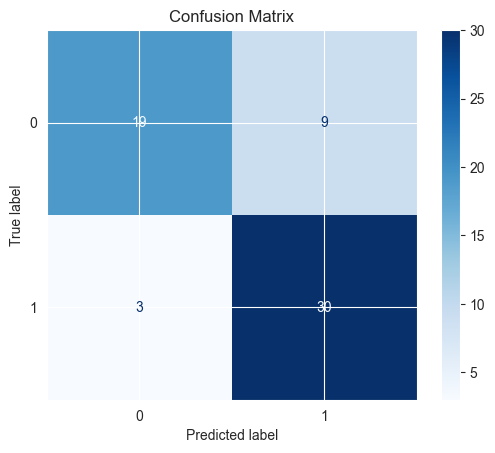

(61,)

In [102]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
y_test.shape

In [103]:
coefficients = pd.Series(log_reg.coef_[0], index=X.columns)
coefficients.sort_values(ascending=False)

cp          0.937735
thalach     0.539629
slope       0.307867
restecg     0.235471
age         0.017736
fbs        -0.063649
trestbps   -0.211437
chol       -0.459210
exang      -0.475883
ca         -0.559203
oldpeak    -0.594819
thal       -0.621578
sex        -0.714030
dtype: float64

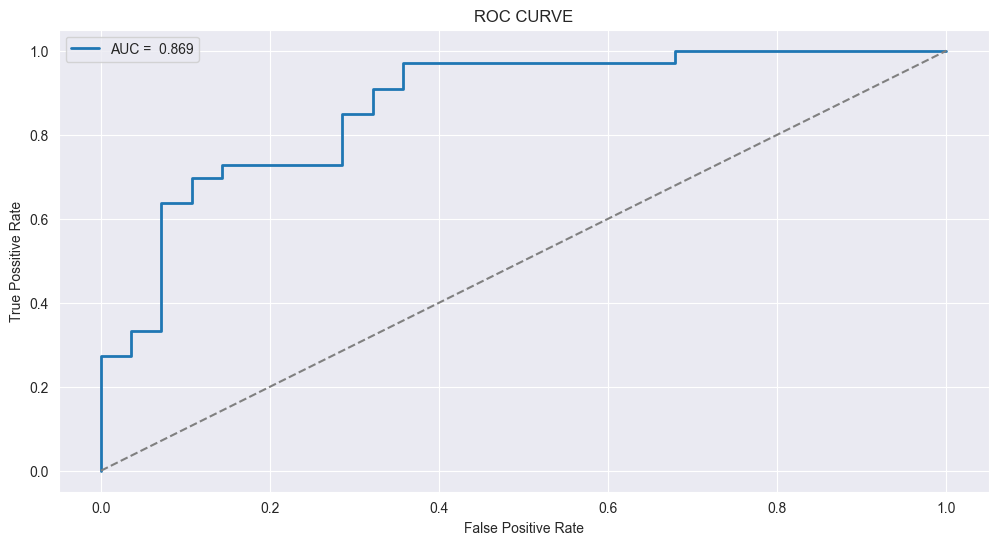

In [104]:
y_probs = log_reg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(12,6))
plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score: .3f}',
    linewidth=2
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'

)

plt.xlabel('False Positive Rate')
plt.ylabel('True Possitive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

In [105]:
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        solver='lbfgs',
        max_iter=1000
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        scoring='roc_auc'
    )

    print(f'C= {C:<5} | mean AUC: {scores.mean():.3} | std = {scores.std():3f}')

C= 0.01  | mean AUC: 0.903 | std = 0.044270
C= 0.1   | mean AUC: 0.906 | std = 0.044082
C= 1     | mean AUC: 0.904 | std = 0.044474
C= 10    | mean AUC: 0.903 | std = 0.046029
C= 100   | mean AUC: 0.903 | std = 0.045751


In [106]:
new_patient = pd.DataFrame([
    {"age": 54,
    "sex": 1,
    "cp": 2,
    "trestbps": 140,
    "chol": 239,
    "fbs": 0,
    "restecg": 1,
    "thalach": 160,
    "exang": 0,
    "oldpeak": 1.2,
    "slope": 2,
    "ca": 0,
    "thal": 2}
])

new_patient = new_patient[X.columns]
new_patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,54,1,2,140,239,0,1,160,0,1.2,2,0,2
